<a href="https://colab.research.google.com/github/uavinash15/Artificial-Intelligence/blob/main/Notebooks/Assignments/XGBM%20%26%20LGBM/XGBM_%26_LGBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LGBM & XGBM**

comparing the performance of Light GBM and XG Boost algorithms using the Titanic dataset.

Exploratory Data Analysis (EDA):

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

Loading the Titanic dataset using Python's pandas library.

In [ ]:
train_df=pd.read_csv('Titanic_train.csv')
test_df=pd.read_csv('Titanic_test.csv')

In [ ]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
train_df.shape

(891, 12)

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
test_df.shape

(418, 11)

In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [ ]:
test_df.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


Checking for missing values.

In [ ]:
train_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
test_df.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


In [ ]:
train_categorical_cls=train_df.select_dtypes(include=['object']).columns.values
train_categorical_cls

array(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype=object)

In [ ]:
test_categorical_cls=test_df.select_dtypes(include=['object']).columns.values
test_categorical_cls

array(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype=object)

In [ ]:
train_numerical_cls=train_df.select_dtypes(include=['float64','int64']).columns.values
train_numerical_cls

array(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch',
       'Fare'], dtype=object)

In [ ]:
test_numerical_cls=test_df.select_dtypes(include=['float64','int64']).columns.values
test_numerical_cls

array(['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'],
      dtype=object)

Histograms

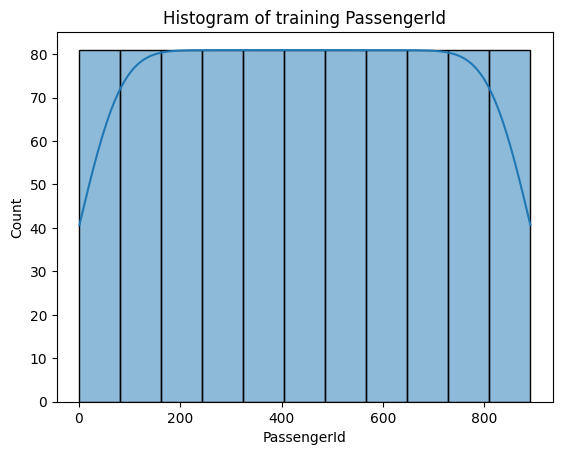

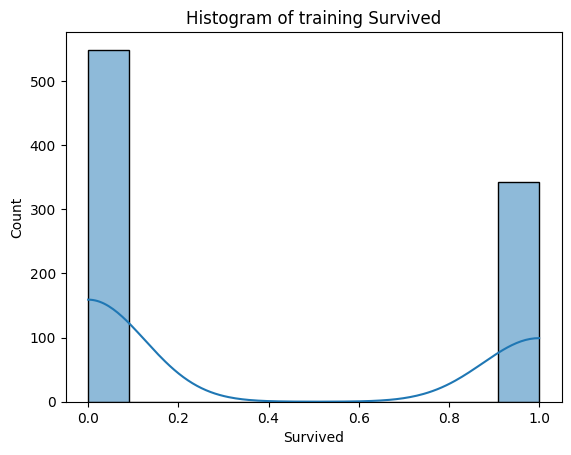

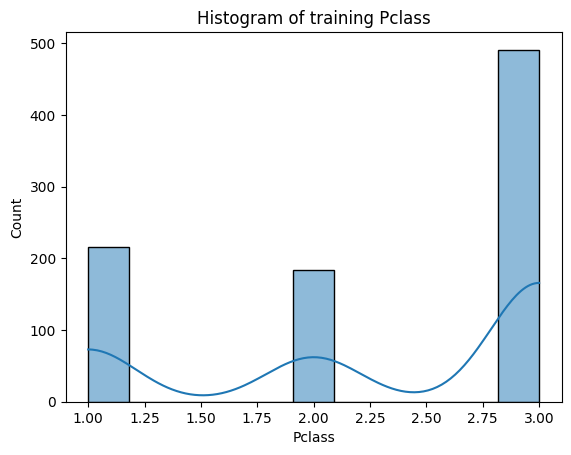

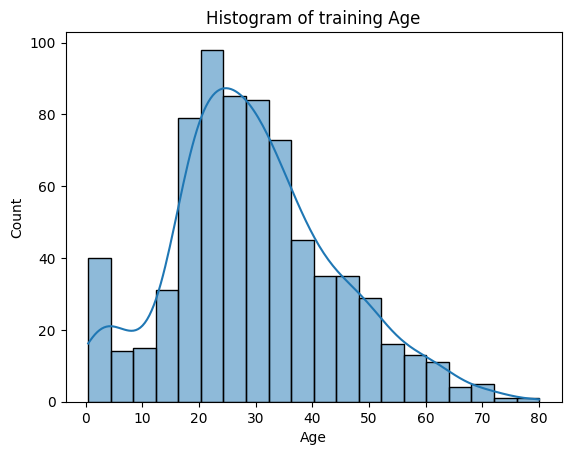

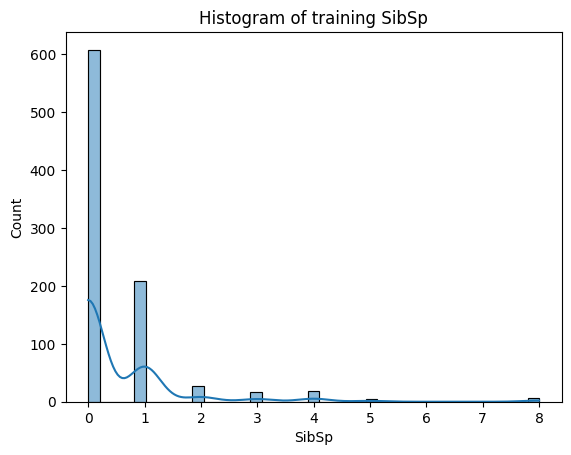

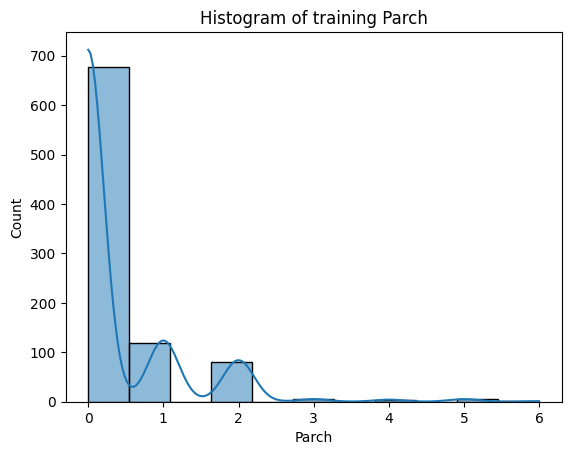

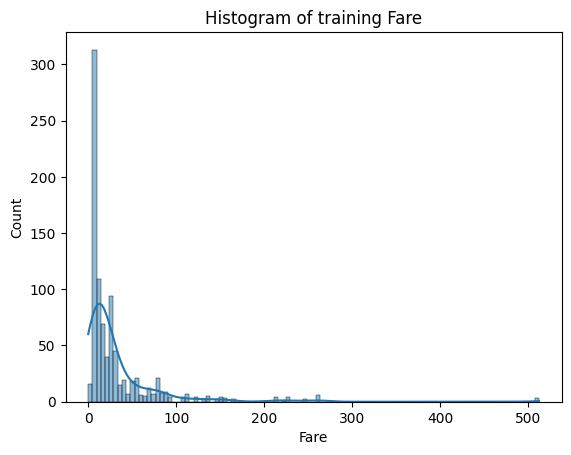

In [ ]:
for col in train_numerical_cls:
    sns.histplot(train_df[col],kde=True)
    plt.title(f"Histogram of training {col}")
    plt.show()
    print(' ')

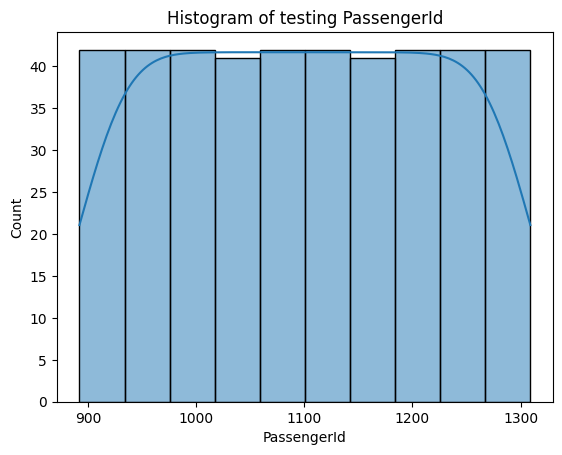

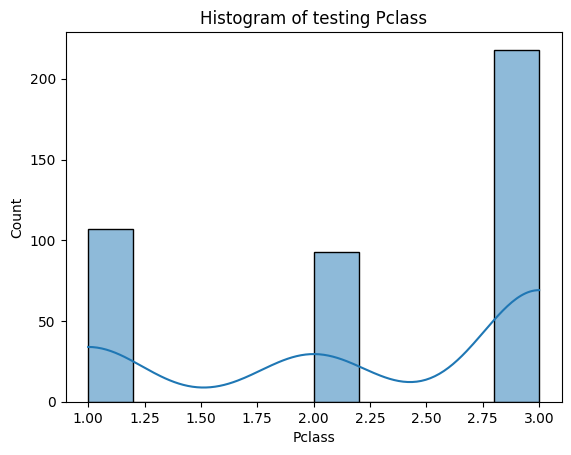

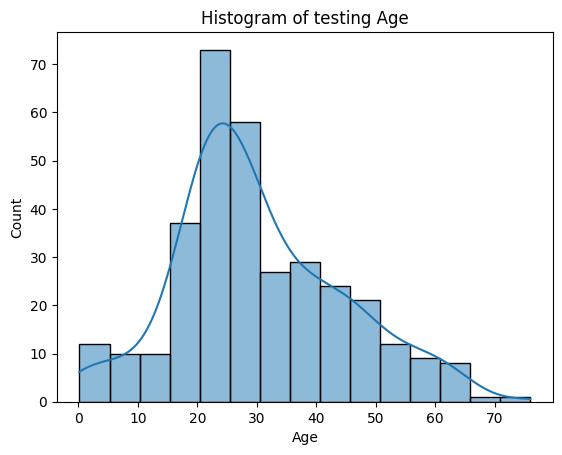

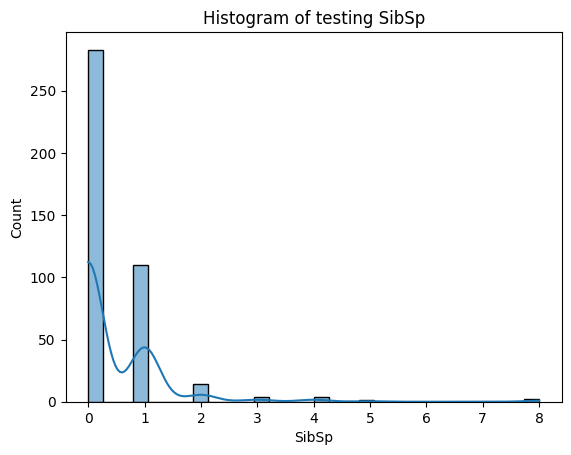

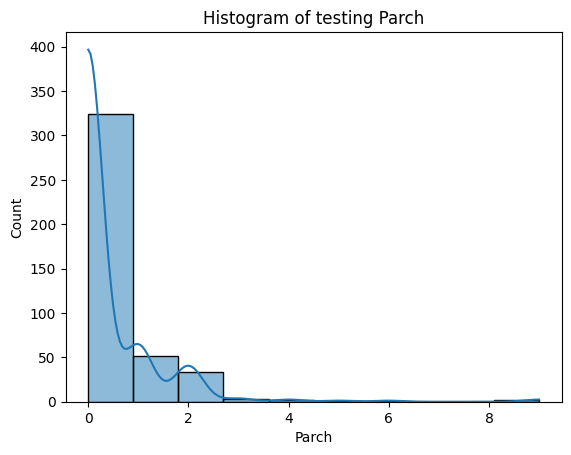

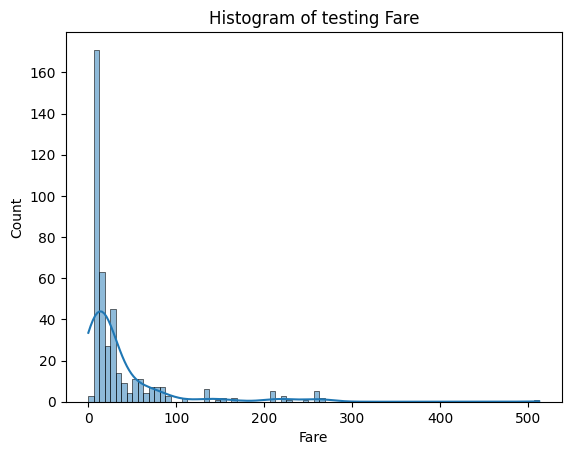

In [ ]:
for col in test_numerical_cls:
    sns.histplot(test_df[col],kde=True)
    plt.title(f"Histogram of testing {col}")
    plt.show()
    print(' ')

Boxplots

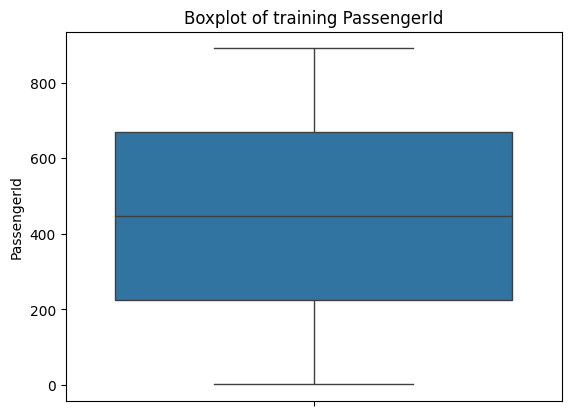

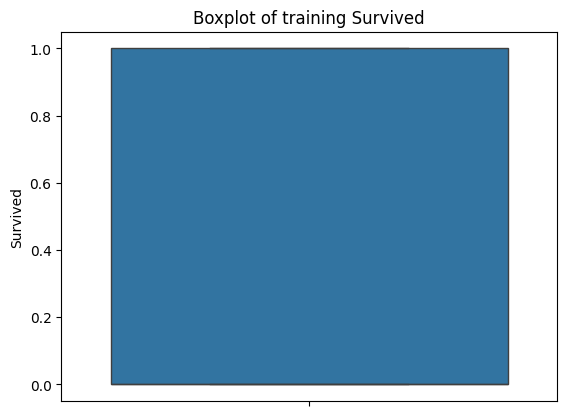

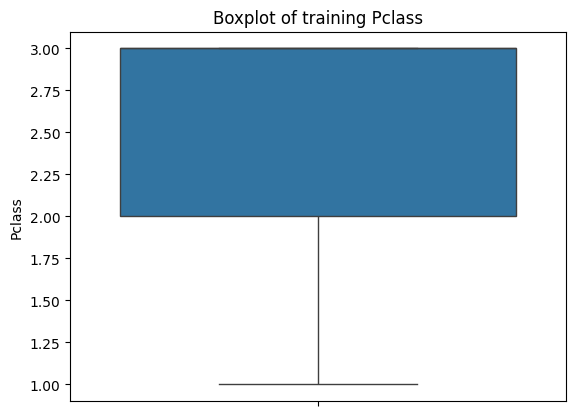

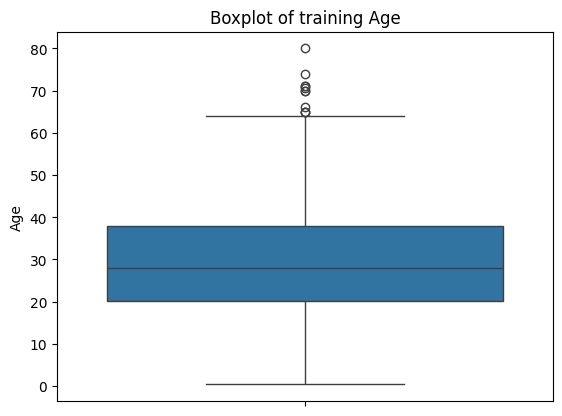

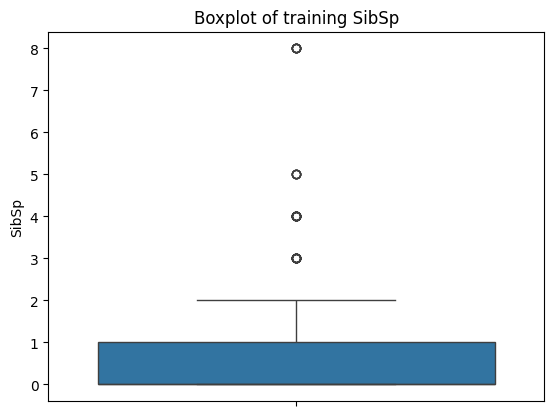

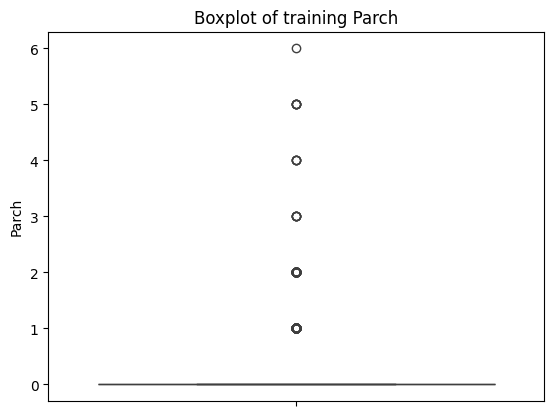

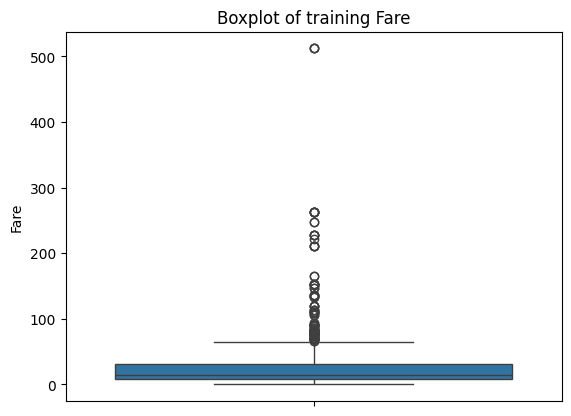

In [ ]:
for col in  train_numerical_cls:
    sns.boxplot(train_df[col])
    plt.title(f"Boxplot of training {col}")
    plt.show()
    print(' ')

In [ ]:
training_cls_outliers=['Fare','Parch','SibSp','Age']

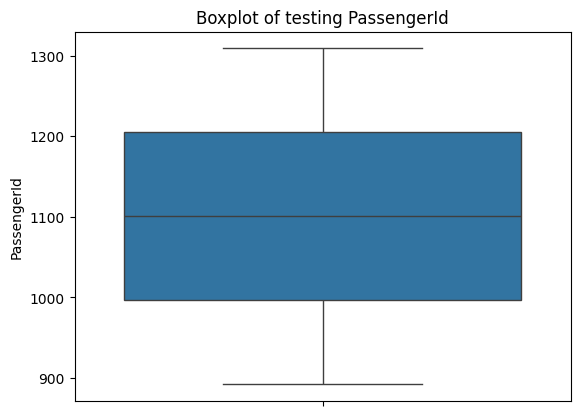

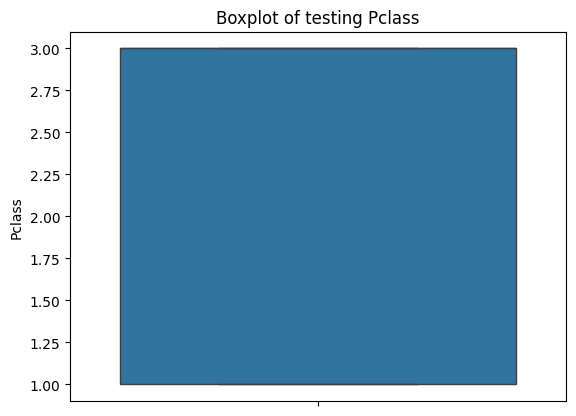

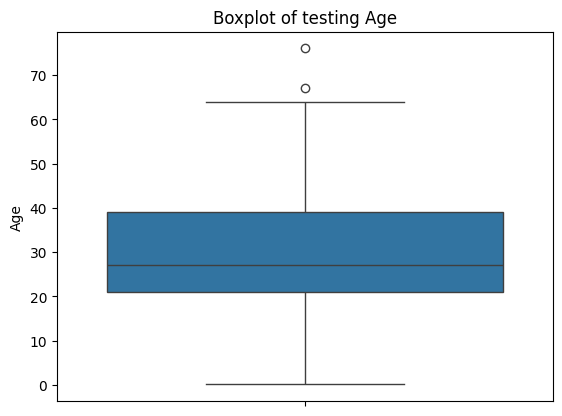

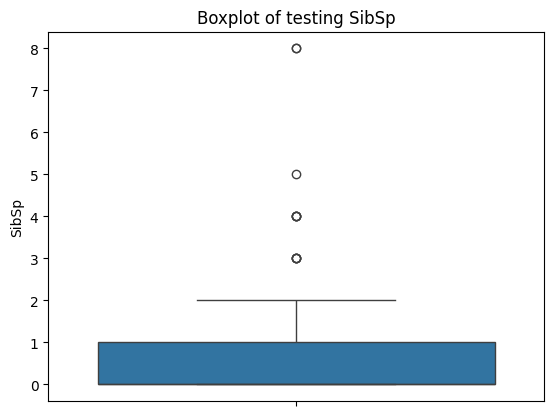

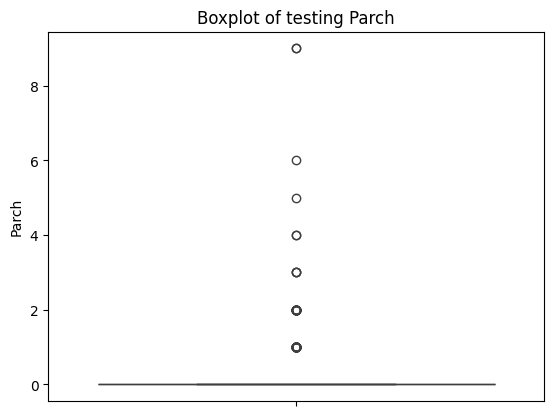

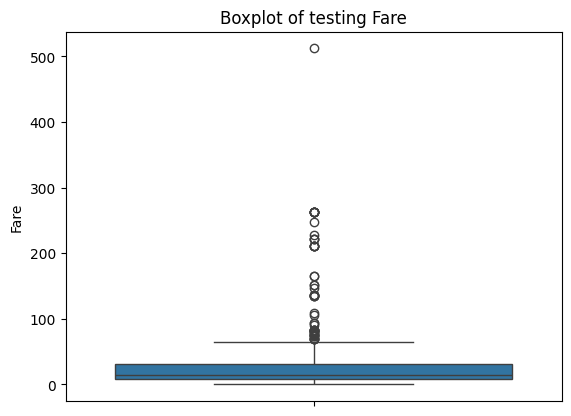

In [ ]:
for col in test_numerical_cls:
    sns.boxplot(test_df[col])
    plt.title(f"Boxplot of testing {col}")
    plt.show()
    print(' ')

In [ ]:
test_cls_outliers=['Fare','Parch','SibSp','Age']

Scatter plots

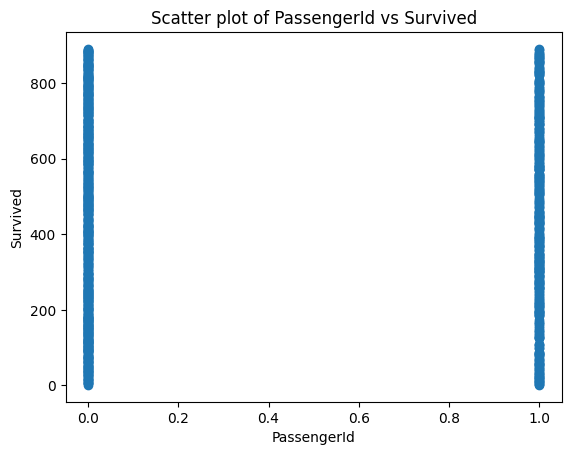

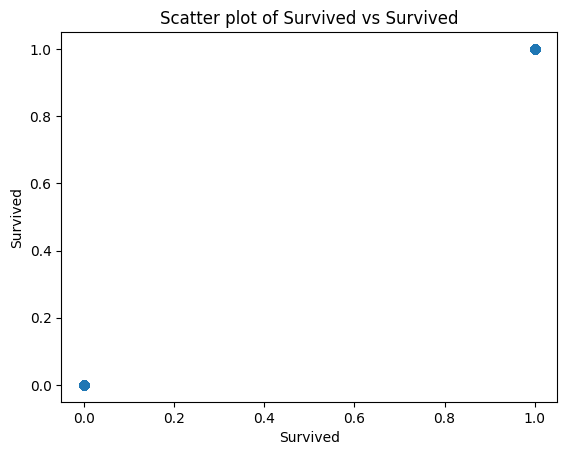

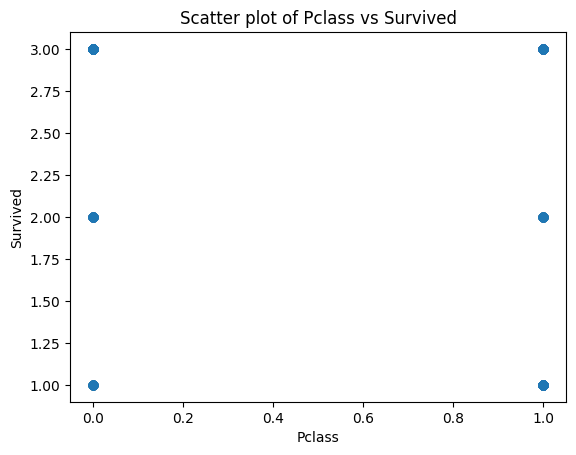

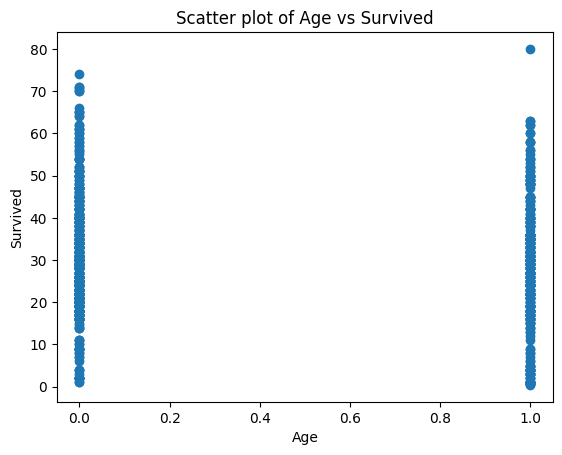

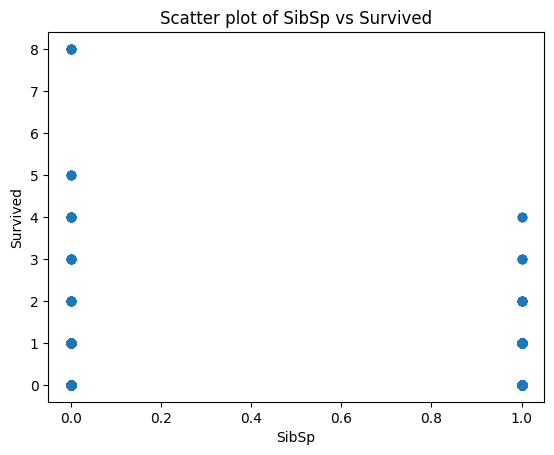

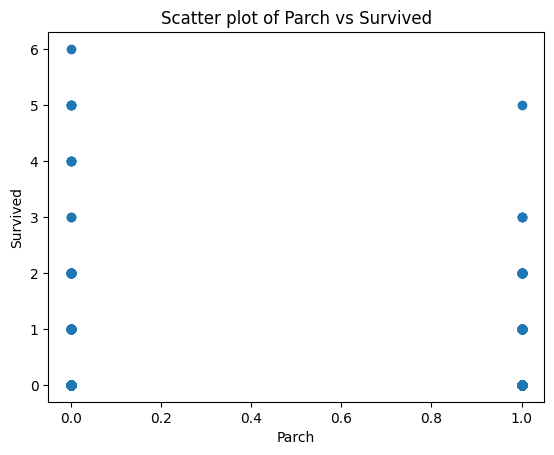

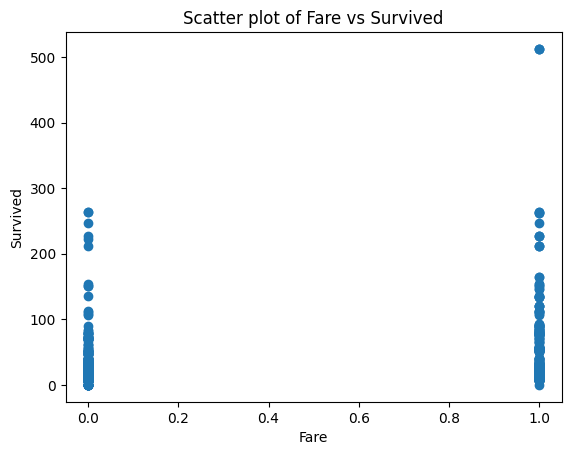

In [ ]:
for col in train_numerical_cls:
  plt.scatter(y=col,x='Survived',data=train_df)
  plt.xlabel(col)
  plt.ylabel('Survived')
  plt.title(f"Scatter plot of {col} vs Survived")
  plt.show()
  print(' ')

Barplot

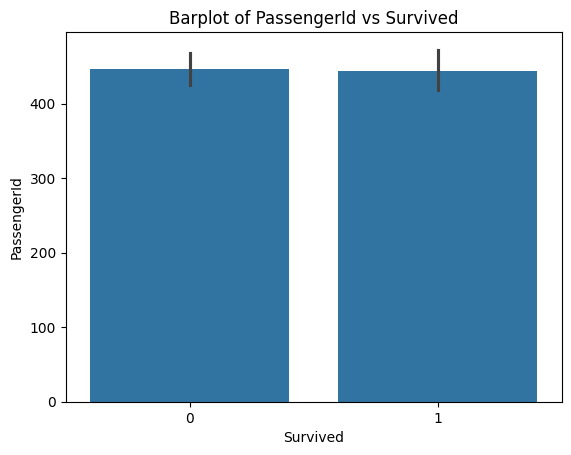

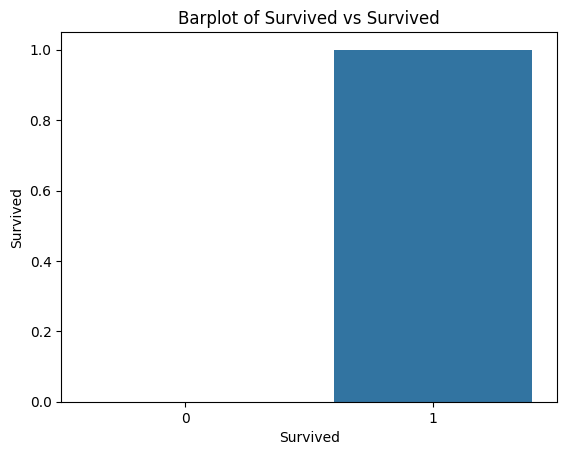

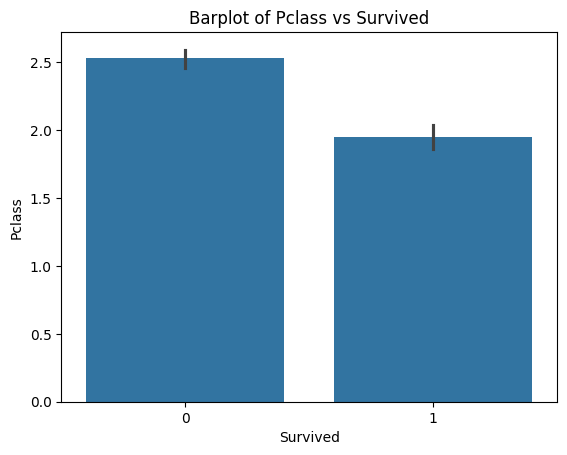

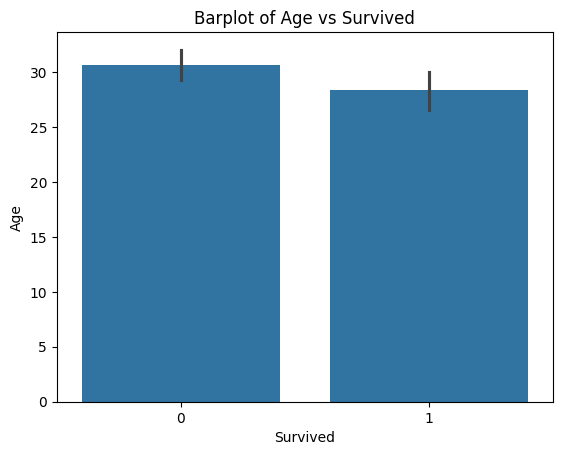

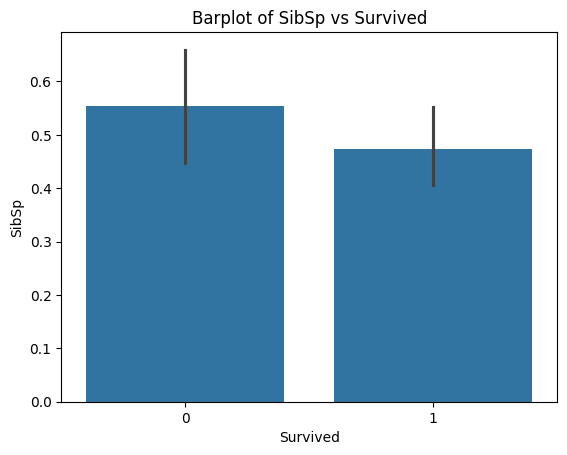

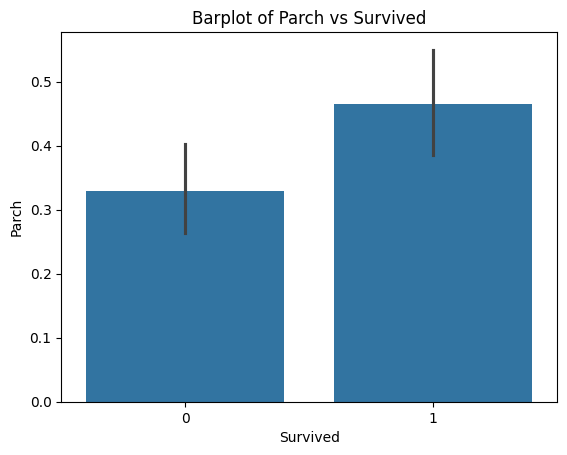

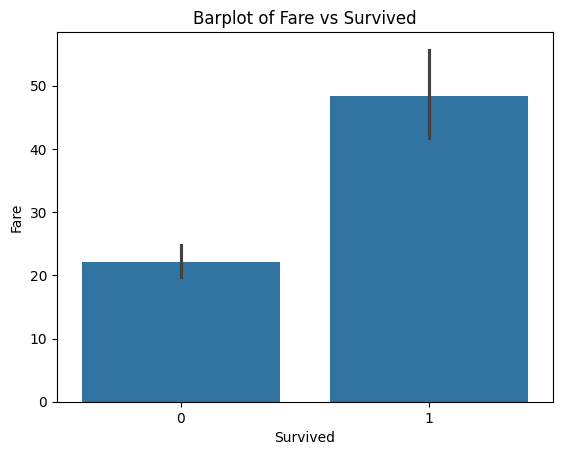

In [ ]:
for col in train_numerical_cls:
  sns.barplot(x='Survived',y=col,data=train_df)
  plt.xlabel('Survived')
  plt.ylabel(col)
  plt.title(f"Barplot of {col} vs Survived")
  plt.show()
  print(' ')

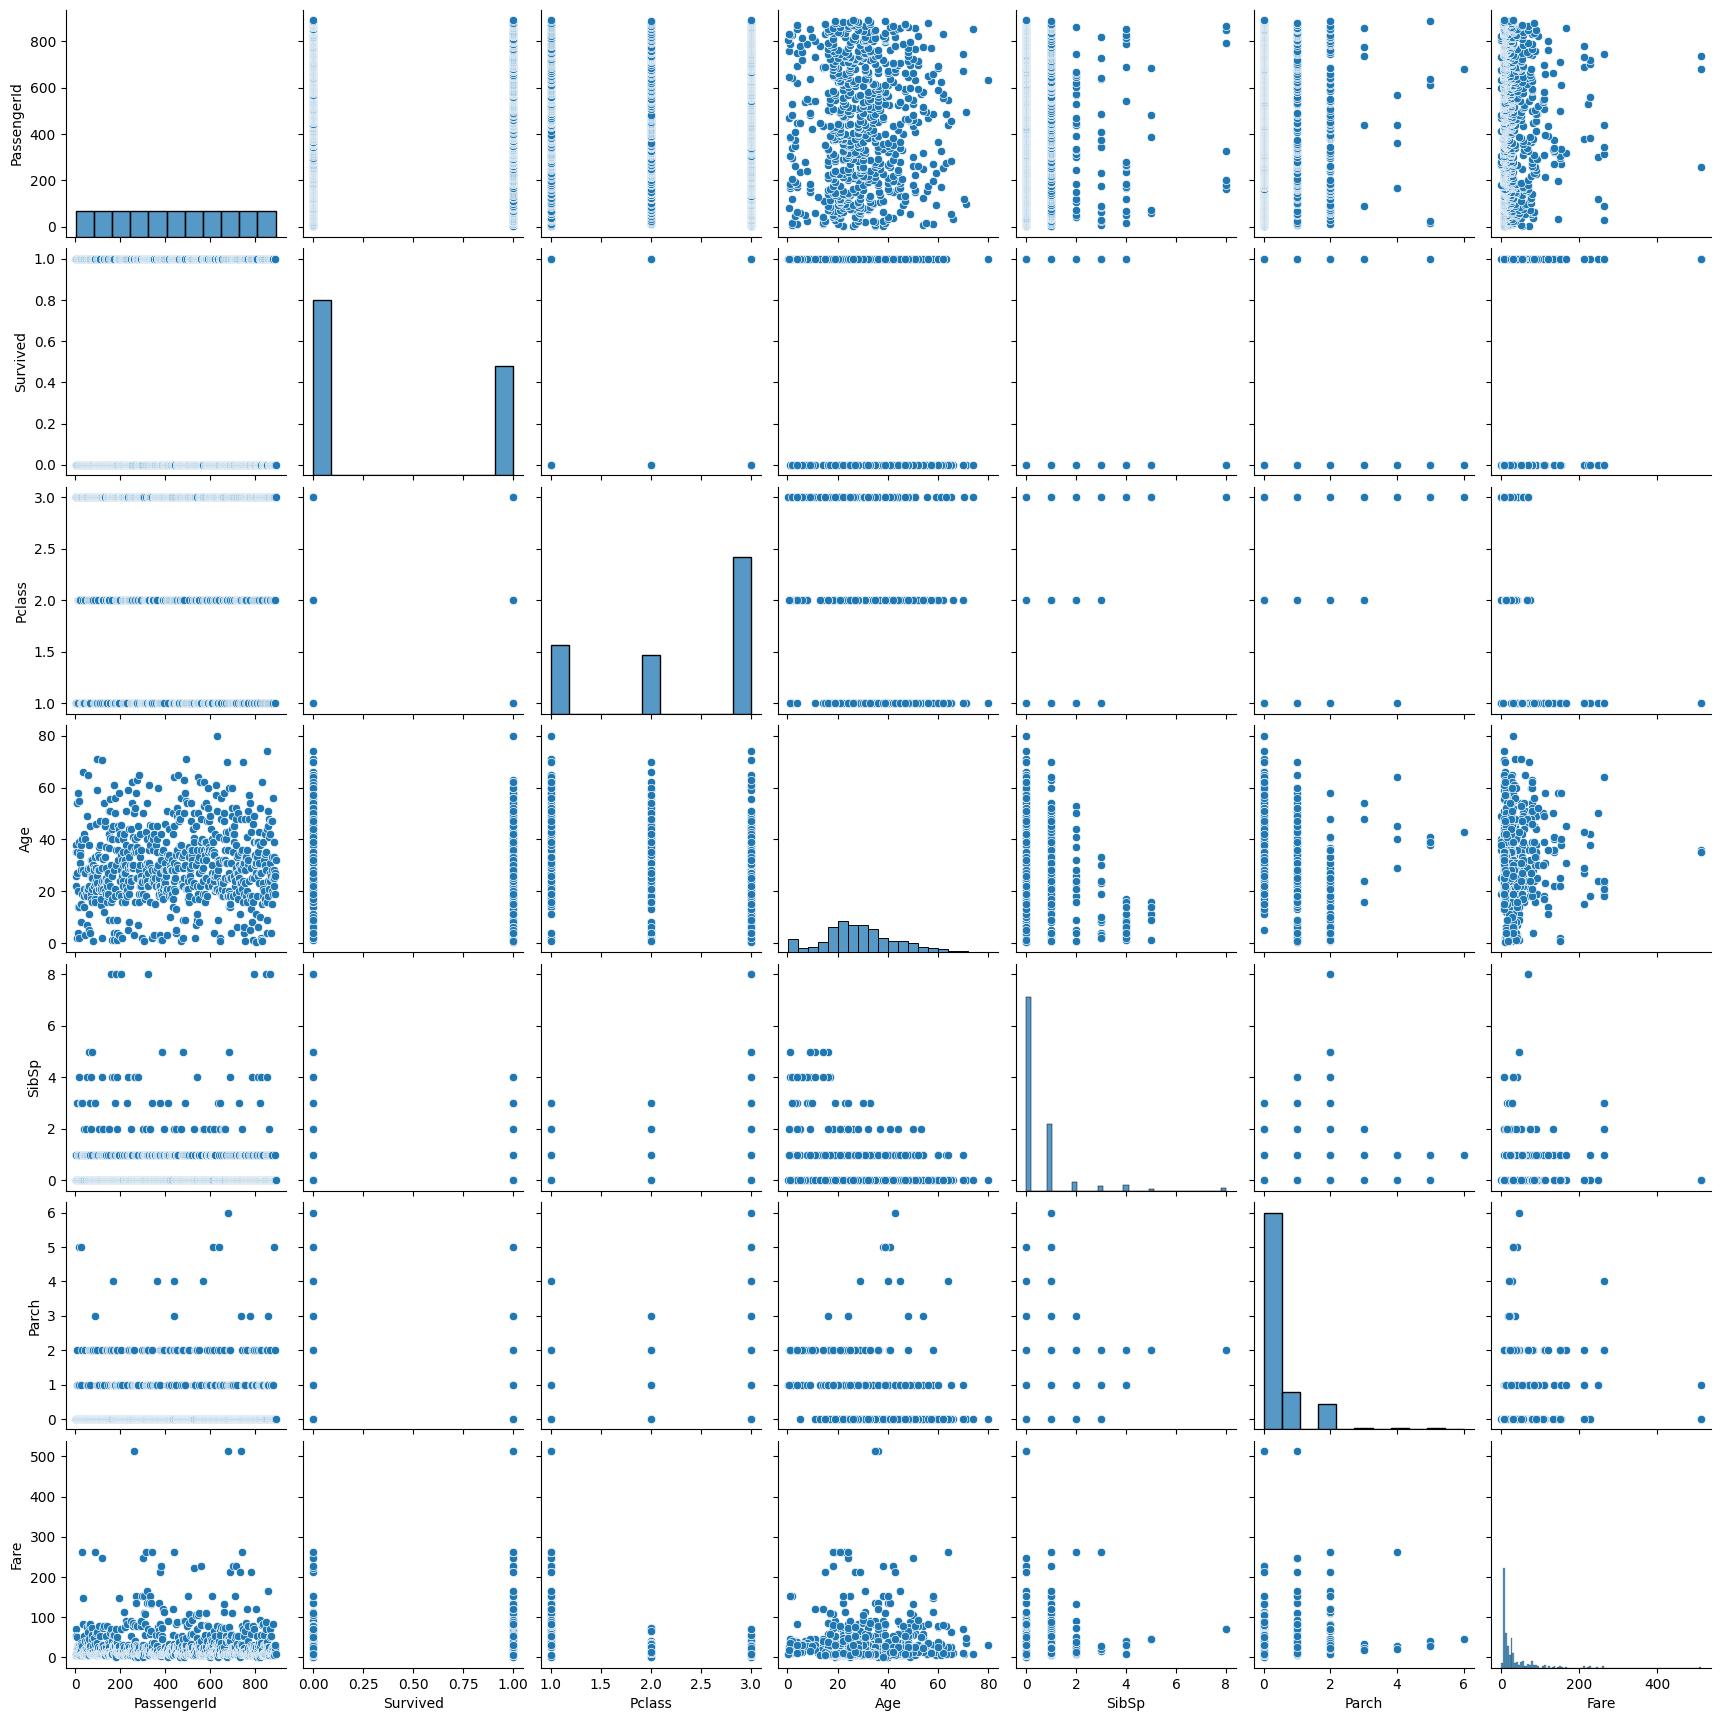

In [ ]:
sns.pairplot(train_df)
plt.show()

Data Preprocessing:

Imputing missing values

In [ ]:
train_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
train_df.Age.fillna(train_df.Age.median(),inplace=True)
train_df.Cabin.fillna('Missing',inplace=True)
train_df.Embarked.fillna('Missing',inplace=True)

In [ ]:
train_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
test_df.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


In [ ]:
test_df.Age.fillna(train_df.Age.median(),inplace=True)
test_df.Cabin.fillna('Missing',inplace=True)
test_df.Fare.fillna(train_df.Fare.median(),inplace=True)

In [ ]:
test_df.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,0


In [ ]:
train_df.Survived.value_counts()

,count
Survived,
0,549
1,342


In [ ]:
train_encoded_df=pd.get_dummies(train_df,columns=train_categorical_cls,drop_first=True).astype(int)
train_encoded_df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,"Name_Abbott, Mr. Rossmore Edward","Name_Abbott, Mrs. Stanton (Rosa Hunt)","Name_Abelson, Mr. Samuel",...,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_Missing,Cabin_T,Embarked_Missing,Embarked_Q,Embarked_S
0,1,0,3,22,1,0,7,0,0,0,...,0,0,0,0,0,1,0,0,0,1
1,2,1,1,38,1,0,71,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,1,3,26,0,0,7,0,0,0,...,0,0,0,0,0,1,0,0,0,1
3,4,1,1,35,1,0,53,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,5,0,3,35,0,0,8,0,0,0,...,0,0,0,0,0,1,0,0,0,1


In [ ]:
Y=train_encoded_df['Survived']
X=train_encoded_df.drop('Survived',axis=1)

Splitting the preprocessed dataset into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [ ]:
(X_train.shape,X_test.shape,Y_train.shape,Y_test.shape)

((712, 1727), (179, 1727), (712,), (179,))

GridSerach for most optimal parameters

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
## Importing GridSearchCV
from sklearn.model_selection import GridSearchCV

## Creating a dictionary with hyperparameters and possible values for searching
tuned_parameters = [{'n_neighbors': range(5,10),
                     'metric': ['canberra', 'euclidean', 'minkowski']}]

## Configuring grid search
clf = GridSearchCV(KNeighborsClassifier(),
                 tuned_parameters,
                 cv=10,
                 scoring='roc_auc')
## fit the search with training set
clf.fit(X_train,Y_train)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid=[{'metric': ['canberra', 'euclidean', 'minkowski'],
                          'n_neighbors': range(5, 10)}],
             scoring='roc_auc')

In [ ]:
clf.best_score_

np.float64(0.8303509453509452)

In [ ]:
clf.best_params_

{'metric': 'canberra', 'n_neighbors': 6}

In [ ]:
clf.cv_results_

{'mean_fit_time': array([0.0286305 , 0.03664153, 0.02546742, 0.02676067, 0.02618363,
        0.03534772, 0.0364979 , 0.03794453, 0.03692822, 0.0368433 ,
        0.03709621, 0.04263926, 0.06365547, 0.0606154 , 0.04418409]),
 'std_fit_time': array([0.0055202 , 0.0049908 , 0.00139408, 0.00366951, 0.00134977,
        0.00310311, 0.00112908, 0.0043134 , 0.0015849 , 0.00120577,
        0.0015837 , 0.00773135, 0.01764117, 0.01802198, 0.00901863]),
 'mean_score_time': array([0.14732478, 0.1901778 , 0.13134143, 0.12920945, 0.12882624,
        0.03511367, 0.03516302, 0.03506997, 0.03673875, 0.03640776,
        0.03511629, 0.04007227, 0.07124476, 0.05544243, 0.0441587 ]),
 'std_score_time': array([0.02704586, 0.02593655, 0.00792255, 0.00550133, 0.00416737,
        0.00510278, 0.00182235, 0.0023014 , 0.00693892, 0.00641631,
        0.00107247, 0.00681848, 0.01571382, 0.01443598, 0.01252699]),
 'param_metric': masked_array(data=['canberra', 'canberra', 'canberra', 'canberra',
                    'c

In [ ]:
## Importing Gradient Boosting classifier
from sklearn.ensemble import GradientBoostingClassifier

## Initializing Gradient Boosting with 500 estimators and max depth as 10.
gboost_clf = GradientBoostingClassifier( n_estimators=500, max_depth=10)

## Fitting gradient boosting model to training set
gboost_clf.fit(X_train,Y_train )

GradientBoostingClassifier(max_depth=10, n_estimators=500)

In [ ]:
from sklearn.model_selection import cross_val_score

gboost_clf = GradientBoostingClassifier( n_estimators=500, max_depth=10)
cv_scores = cross_val_score( gboost_clf, X_train,Y_train, cv = 10, scoring = 'roc_auc' )

In [ ]:
print( cv_scores )
print( "Mean Accuracy: ", np.mean(cv_scores), " with standard deviation of: ",  np.std(cv_scores))

[0.92427984 0.81111111 0.7017094  0.93846154 0.85774411 0.80008418
 0.82449495 0.84090909 0.8202862  0.97053872]
Mean Accuracy:  0.8489619125730237  with standard deviation of:  0.07451967193221513


In [ ]:
!pip install lightgbm xgboost

In [ ]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

LGBM

In [ ]:
import re

# Sanitize column names for X_train and X_test
X_train.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in X_train.columns]
X_test.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in X_test.columns]

lightgbm_clf = LGBMClassifier(n_estimators=500, max_depth=10)
lightgbm_clf.fit(X_train, Y_train)
print("LGBMClassifier re-initialized and fitted successfully.")

[LightGBM] [Info] Number of positive: 268, number of negative: 444
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000329 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 383
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376404 -> initscore=-0.504838
[LightGBM] [Info] Start training from score -0.504838
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

In [ ]:
import lightgbm as lgb
d_train = lgb.Dataset(X_train, label=Y_train)
d_train

In [ ]:
params = {}
params['learning_rate'] = 0.003
params['boosting_type'] = 'gbdt'
params['objective'] = 'binary'
params['metric'] = 'binary_logloss'
params['sub_feature'] = 0.5
params['num_leaves'] = 10
params['min_data'] = 50
params['max_depth'] = 10

In [ ]:
clf = lgb.train(params, d_train, 500)

[LightGBM] [Info] Number of positive: 268, number of negative: 444
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.036635 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 383
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376404 -> initscore=-0.504838
[LightGBM] [Info] Start training from score -0.504838
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

In [ ]:
y_pred=clf.predict(x_test)

In [ ]:
test_df.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,0


In [ ]:
test_encoded_df=pd.get_dummies(test_df,columns=test_categorical_cls,drop_first=True).astype(int)
test_encoded_df.head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,"Name_Abelseth, Miss. Karen Marie","Name_Abelseth, Mr. Olaus Jorgensen","Name_Abrahamsson, Mr. Abraham August Johannes","Name_Abrahim, Mrs. Joseph (Sophie Halaut Easu)",...,Cabin_F E46,Cabin_F E57,Cabin_F G63,Cabin_F2,Cabin_F33,Cabin_F4,Cabin_G6,Cabin_Missing,Embarked_Q,Embarked_S
0,892,3,34,0,0,7,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
1,893,3,47,1,0,7,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
2,894,2,62,0,0,9,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
3,895,3,27,0,0,8,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
4,896,3,22,1,1,12,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1


In [ ]:
train_encoded_df.shape

(891, 1728)

In [ ]:
test_encoded_df.shape

(418, 864)

In [ ]:
train_encoded_df=train_encoded_df.drop('PassengerId',axis=1)
train_encoded_df.columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
       'Name_Abbott, Mr. Rossmore Edward',
       'Name_Abbott, Mrs. Stanton (Rosa Hunt)', 'Name_Abelson, Mr. Samuel',
       'Name_Abelson, Mrs. Samuel (Hannah Wizosky)',
       ...
       'Cabin_F2', 'Cabin_F33', 'Cabin_F38', 'Cabin_F4', 'Cabin_G6',
       'Cabin_Missing', 'Cabin_T', 'Embarked_Missing', 'Embarked_Q',
       'Embarked_S'],
      dtype='object', length=1727)

In [ ]:
test_encoded_df=test_encoded_df.drop('PassengerId',axis=1)
test_encoded_df.columns

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
       'Name_Abelseth, Miss. Karen Marie',
       'Name_Abelseth, Mr. Olaus Jorgensen',
       'Name_Abrahamsson, Mr. Abraham August Johannes',
       'Name_Abrahim, Mrs. Joseph (Sophie Halaut Easu)',
       'Name_Aks, Master. Philip Frank',
       ...
       'Cabin_F E46', 'Cabin_F E57', 'Cabin_F G63', 'Cabin_F2', 'Cabin_F33',
       'Cabin_F4', 'Cabin_G6', 'Cabin_Missing', 'Embarked_Q', 'Embarked_S'],
      dtype='object', length=863)

In [ ]:
Y=train_encoded_df['Survived']
X=train_encoded_df.drop('Survived',axis=1)

In [ ]:
Y.head()

,Survived
0,0
1,1
2,1
3,1
4,0


In [ ]:
Y.shape

(891,)

In [ ]:
X.head()

,Pclass,Age,SibSp,Parch,Fare,"Name_Abbott, Mr. Rossmore Edward","Name_Abbott, Mrs. Stanton (Rosa Hunt)","Name_Abelson, Mr. Samuel","Name_Abelson, Mrs. Samuel (Hannah Wizosky)","Name_Adahl, Mr. Mauritz Nils Martin",...,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_Missing,Cabin_T,Embarked_Missing,Embarked_Q,Embarked_S
0,3,22,1,0,7,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
1,1,38,1,0,71,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,26,0,0,7,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
3,1,35,1,0,53,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,3,35,0,0,8,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1


In [ ]:
X.shape

(891, 1726)

Splitting the preprocessed dataset into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [ ]:
(X_train.shape,X_test.shape,Y_train.shape,Y_test.shape)

((712, 1726), (179, 1726), (712,), (179,))

Building predictive models

In [ ]:
!pip install lightgbm xgboost

In [ ]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

XGBM

In [ ]:
model = XGBClassifier(max_depth =6,
                      n_estimators=500,
                      learning_rate=0.03,
                      gamma=0.5,
                      objective='binary:logistic',
                      booster='gbtree')
model.fit(X_train,Y_train)

XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.5, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test)
predictions = [round(value) for value in y_pred]

In [ ]:
from sklearn.metrics import accuracy_score

#evaluate predictions
accuracy = accuracy_score(Y_test, predictions)
print("Accuracy: %.2f" % (accuracy * 100.0))

Accuracy: 83.24


In [ ]:
print(predictions)

[0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1]


LGBM

In [ ]:
import lightgbm as lgb
d_train = lgb.Dataset(X_train, label=Y_train)

In [ ]:
params = {}
params['learning_rate'] = 0.05
params['boosting_type'] = 'gbdt'
params['objective'] = 'binary'
params['metric'] = 'binary_logloss'
params['sub_feature'] = 0.5
params['num_leaves'] = 31
params['min_data'] = 20
params['max_depth'] = 10

In [ ]:
import re
X_train.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in X_train.columns]
X_test.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in X_test.columns]

# Recreate d_train with sanitized column names
d_train = lgb.Dataset(X_train, label=Y_train)

clf = lgb.train(params, d_train, 500)

[LightGBM] [Info] Number of positive: 268, number of negative: 444
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000398 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 145
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376404 -> initscore=-0.504838
[LightGBM] [Info] Start training from score -0.504838
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [ ]:
y_pred=clf.predict(X_test)

In [ ]:
predictions = [round(value) for value in y_pred]

In [ ]:
print(predictions)

[0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1]


In [ ]:
accuracy = accuracy_score(Y_test, predictions)
accuracy

0.8044692737430168